In [22]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])

In [24]:
henon = tanglepack.DynamicalSystem(henon_map, henon_map_inverse)
fp_solver = tanglepack.FixedPointSolver(henon)
man_maker = tanglepack.ManifoldInitializer(henon)
man_machine = tanglepack.ManifoldMachine(henon)

tangle = tanglepack.Tangle()

initial_guess = [4, -4]

fixed_point = fp_solver.construct_fixed_point(initial_guess, 2)

print(f"The fixed point is: {fixed_point.coordinates[0]}")

approx_dirs = {"unstable": np.array([-1, 0]), "stable": np.array([0, 1])}

man_maker.orient_manifolds(fixed_point, approx_dirs)

eigenvalues: [8.51582066 0.11742849]
The fixed point is: [ 4.31662458 -4.31662318]


In [25]:
initial_stable_segment = man_maker.construct_kevin_way(fixed_point, "stable")

initial_unstable_segment = man_maker.construct_kevin_way(fixed_point, "unstable")

unstable_manifold = initial_unstable_segment[(0, 0)]
stable_manifold = initial_stable_segment[(0, 0)]

num_iterations = 6

# grow unstable manfold
man_machine.grow_x_times(fixed_point, "unstable", num_iterations)
unstable_manifold._find_tail()

# grow stable manifold
man_machine.grow_x_times(fixed_point, "stable", num_iterations)
stable_manifold._find_tail()

14:02:14 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 3 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 7 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 51 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 62 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 86 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 203 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 2121 Points added during refinement
14:02:14 INFO     tanglepack.ManifoldMachine: 2465 NUMBER OF CURRENT POINTS
14:02:14 INFO     tanglepack.ManifoldMachine: 0 Points added during refinemen

In [26]:
def intersections():
    tangle.add_manifold(unstable_manifold)
    tangle.add_manifold(stable_manifold)

    unstable_ids = tangle._manifold_segs[unstable_manifold]
    stable_ids = tangle._manifold_segs[stable_manifold]

    hits = []  # (segA, segB) pairs

    for sid in unstable_ids:
        segA = tangle._seg_lookup[sid]
        for segB in tangle.intersections_for_segment(segA):
            hits.append((segA, segB))

intersections()
tangle.populate_intersection_dict()
print(f"Intersections: {tangle._intersecting_coords.values()}")
print(f"Num intersections: {len(tangle._intersecting_coords)}")

Intersections: dict_values([array([3.18313124, 4.04528526]), array([3.31821472, 3.18298515]), array([1.78792552, 2.92629345]), array([1.78792552, 2.92629345]), array([ 4.31662458, -4.31662318]), array([ 4.31662458, -4.31662318]), array([1.52257825, 3.83853882]), array([1.52257825, 3.83853882]), array([ 2.99478619, -2.99470703]), array([ 2.99478619, -2.99470703]), array([-2.92651466, -1.78827206]), array([-2.92651466, -1.78827206]), array([-3.38909681,  1.79488925]), array([-3.38909681,  1.79488925]), array([ 4.18073824, -3.18352353]), array([ 4.18073824, -3.18352353]), array([-3.83849803, -1.5229433 ]), array([-3.83849803, -1.5229433 ]), array([-2.12776196,  2.12779724]), array([-2.12776196,  2.12779724]), array([-1.794087  ,  3.38930205]), array([-1.794087  ,  3.38930205]), array([3.31821472, 3.18298515]), array([-4.04526848, -3.18340964]), array([-4.04526848, -3.18340964]), array([-3.18327641,  3.18335461]), array([-3.18327641,  3.18335461]), array([-3.18310349, -3.31852884]), array(

(-15.0, 15.0)

14:02:23 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


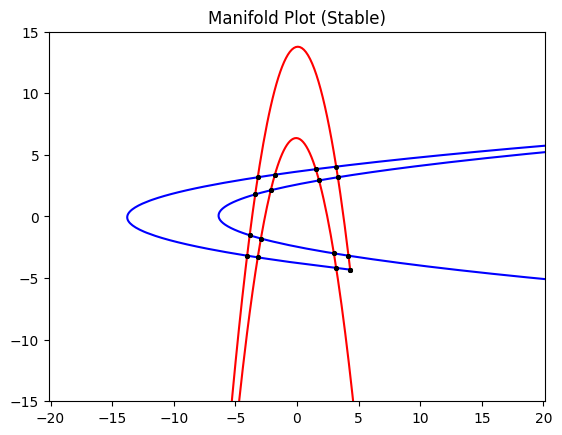

In [27]:
fig = plt.figure()

show_points = False
unstable_manifold.plot("blue", show_points=show_points)
stable_manifold.plot("red", show_points=show_points)
plt.scatter(*fixed_point.coordinates[0], c="k", s=7)

for point in tangle._intersecting_coords.values():
    plt.scatter(*point, c="k", s=7, zorder=10)

plt.xlim([-15, 15])
plt.ylim([-15, 15])

In [28]:
bridges = tangle.create_bridges()
print(f"Number of bridges: {len(bridges)}")
print(bridges)

Number of bridges: 15
[<tanglepack.Bridge.Bridge object at 0x7f4800fa08f0>, <tanglepack.Bridge.Bridge object at 0x7f4800ecbdd0>, <tanglepack.Bridge.Bridge object at 0x7f4800ecb4a0>, <tanglepack.Bridge.Bridge object at 0x7f48010ed160>, <tanglepack.Bridge.Bridge object at 0x7f48010ec470>, <tanglepack.Bridge.Bridge object at 0x7f48010ede80>, <tanglepack.Bridge.Bridge object at 0x7f48010ec0e0>, <tanglepack.Bridge.Bridge object at 0x7f48010ec1a0>, <tanglepack.Bridge.Bridge object at 0x7f48010ed4c0>, <tanglepack.Bridge.Bridge object at 0x7f48010ee840>, <tanglepack.Bridge.Bridge object at 0x7f48010ec1d0>, <tanglepack.Bridge.Bridge object at 0x7f48010ec620>, <tanglepack.Bridge.Bridge object at 0x7f48010ee9c0>, <tanglepack.Bridge.Bridge object at 0x7f48010ee570>, <tanglepack.Bridge.Bridge object at 0x7f48010ede50>]


/tmp/ipykernel_652/2744689801.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', n)  # or 'tab10', 'nipy_spectral', etc.
14:02:28 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


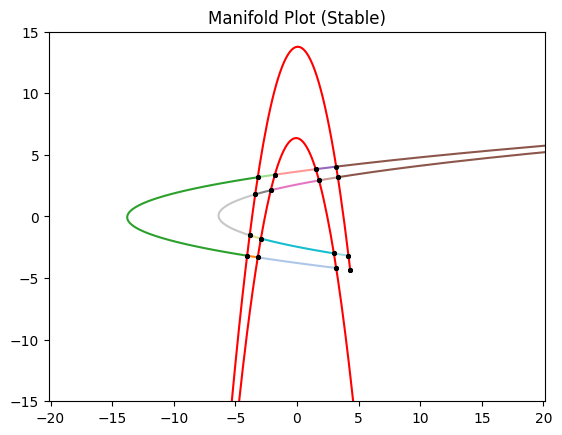

In [29]:
def plot_all_bridges(bridges):
    n = len(bridges)
    colors = cm.get_cmap('tab20', n)  # or 'tab10', 'nipy_spectral', etc.

    for i, bridge in enumerate(bridges):
        if i == 0:
            continue

        vibe = colors(i)
        bridge.plot(color=vibe)

fig = plt.figure()

plot_all_bridges(bridges)

stable_manifold.plot("red", show_points=show_points)

for point in tangle._intersecting_coords.values():
    plt.scatter(*point, c="k", s=7, zorder=10)

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

In [30]:
new_manifold = man_machine.iterate_manifold(bridges[1])

14:02:32 INFO     tanglepack.ManifoldMachine: 7 Points added during refinement
14:02:32 INFO     tanglepack.ManifoldMachine: 60 NUMBER OF CURRENT POINTS


14:02:35 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


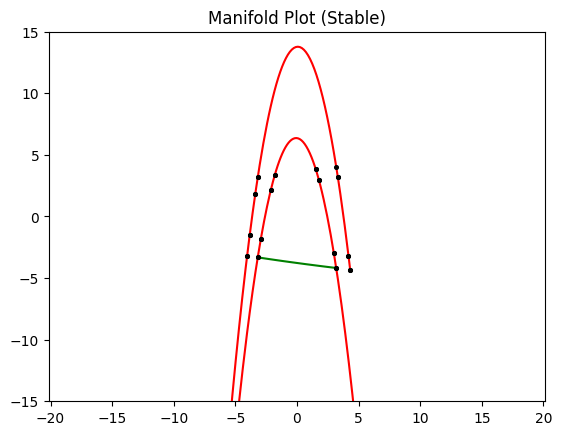

In [31]:
fig = plt.figure()

bridges[1].plot("green")
stable_manifold.plot("red", show_points=show_points)

for point in tangle._intersecting_coords.values():
    plt.scatter(*point, c="k", s=7, zorder=10)

# new_manifold.plot()

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

14:02:42 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


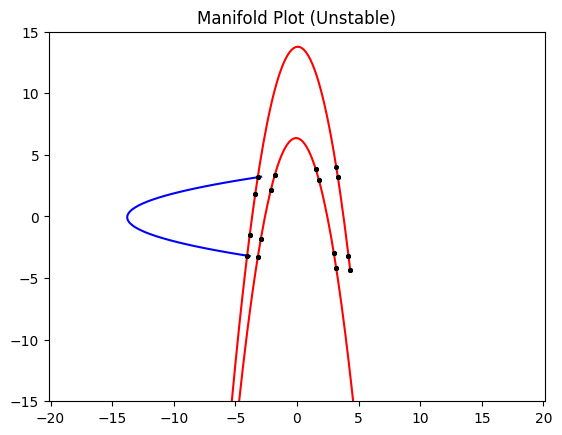

In [32]:
fig = plt.figure()

# bridges[1].plot("green")
stable_manifold.plot("red", show_points=show_points)

for point in tangle._intersecting_coords.values():
    plt.scatter(*point, c="k", s=7, zorder=10)

new_manifold.plot()

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

14:02:52 INFO     tanglepack.ManifoldMachine: 45 Points added during refinement
14:02:52 INFO     tanglepack.ManifoldMachine: 186 NUMBER OF CURRENT POINTS
14:02:52 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


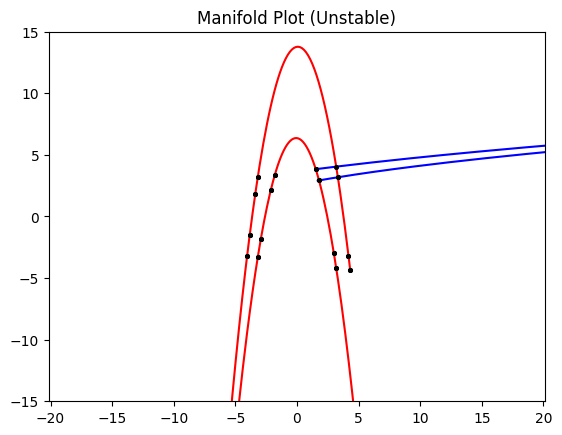

In [33]:
fig = plt.figure()

# bridges[1].plot("green")
stable_manifold.plot("red", show_points=show_points)

new_manifold = man_machine.iterate_manifold(new_manifold)

for point in tangle._intersecting_coords.values():
    plt.scatter(*point, c="k", s=7, zorder=10)

new_manifold.plot()

plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()